In [2]:
import os
import pandas as pd
from Sequential_Fish.tools import safe_merge_no_duplicates
from Sequential_Fish.analysis.post_processing import Spots_filtering

RUN_PATH = "/media/SSD_floricslimani/Fish_seq/POLR2/2026-03-24 - HeLa_POLR2_Run17_tiff/"

# Visualize Spots

In [3]:
Gene_map = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Gene_map.feather"))
Detection = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Detection.feather"))
Spots = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Spots.feather"))
Acquisition = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Acquisition.feather"))
Cell = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Cell.feather"))

In [4]:
# Spots = Spots_filtering(
#     Spots=Spots,
#     Detection=Detection,
#     Cell=Cell,
#     segmentation_filter=False,
#     filter_washout=False
# )

Detection = safe_merge_no_duplicates(
    Detection,
    Acquisition,
    on= ['acquisition_id'],
    keys=['cycle','location', 'fish_reodered_shape']
)

Detection = safe_merge_no_duplicates(
    Detection,
    Gene_map,
    on= ['cycle','color_id'],
    keys=['target']
)

Spots =safe_merge_no_duplicates(
    Spots,
    Detection,
    on= ['detection_id','color_id'],
    keys= ['location','target', 'voxel_size', 'fish_reodered_shape']
)

# Spots = safe_merge_no_duplicates(
#     Spots,
#     Cell.rename(columns={'label' : 'cell_label'}),
#     on=['acquisition_id','detection_id','cell_label'],
#     keys=['cell_id']
# )

In [5]:
Spots_nowashout = Spots.loc[~Spots["is_washout"]]
Spots_nowashout = Spots_nowashout[Spots_nowashout["cell_label"] != 0]
Spots_nowashout.groupby(["location","color_id","target"]).agg({
    "cell_label" : lambda x : len(pd.unique(x)),
    "spot_id" : "count",
    }).sort_index()

cell_label  spot_id
location    color_id target                              
Location-01 0        POLR2A                   41    10817
                     POLR2A_endcycle          41     2901
                     POLR2B                   41     1901
                     POLR2C                   41     2373
                     POLR2E                   41     3841
...                                          ...      ...
Location-30 1        POLR2I                   29      790
                     POLR2J                   29     3004
                     POLR2K                   29      858
                     POLR2L                   29     2224
                     PRPF8_endcycle           29     2655

[480 rows x 2 columns]

In [6]:
import matplotlib.pyplot as plt
from my_plots.super_plot import distribution_super_plot

In [7]:
data = Spots_nowashout.groupby(["target","location","cell_label"])["spot_id"].count().squeeze()
data = data.groupby(["target","location"]).apply(list)
data.index = pd.MultiIndex.from_tuples(zip(
    data.index.get_level_values(0).astype(str),
    data.index.get_level_values(1),
    ))
data.index.names = ["target","location"]
data = data.sort_index(axis=0)
data

target          location   
ANXA5           Location-01    [68, 190, 169, 282, 247, 206, 424, 199, 146, 1...
                Location-02    [218, 216, 276, 165, 184, 205, 132, 213, 149, ...
                Location-03    [252, 68, 173, 262, 123, 143, 212, 247, 162, 9...
                Location-04    [239, 211, 179, 258, 242, 220, 235, 176, 201, ...
                Location-05    [89, 129, 97, 311, 236, 109, 228, 5, 300, 256,...
                                                     ...                        
PRPF8_endcycle  Location-26    [67, 74, 114, 114, 68, 69, 97, 73, 88, 73, 81,...
                Location-27    [32, 73, 150, 68, 80, 85, 77, 131, 111, 95, 85...
                Location-28    [25, 65, 107, 89, 111, 92, 129, 87, 64, 121, 5...
                Location-29    [103, 82, 102, 106, 80, 67, 72, 77, 65, 66, 64...
                Location-30    [91, 90, 79, 83, 71, 53, 78, 98, 79, 48, 69, 7...
Name: spot_id, Length: 480, dtype: object

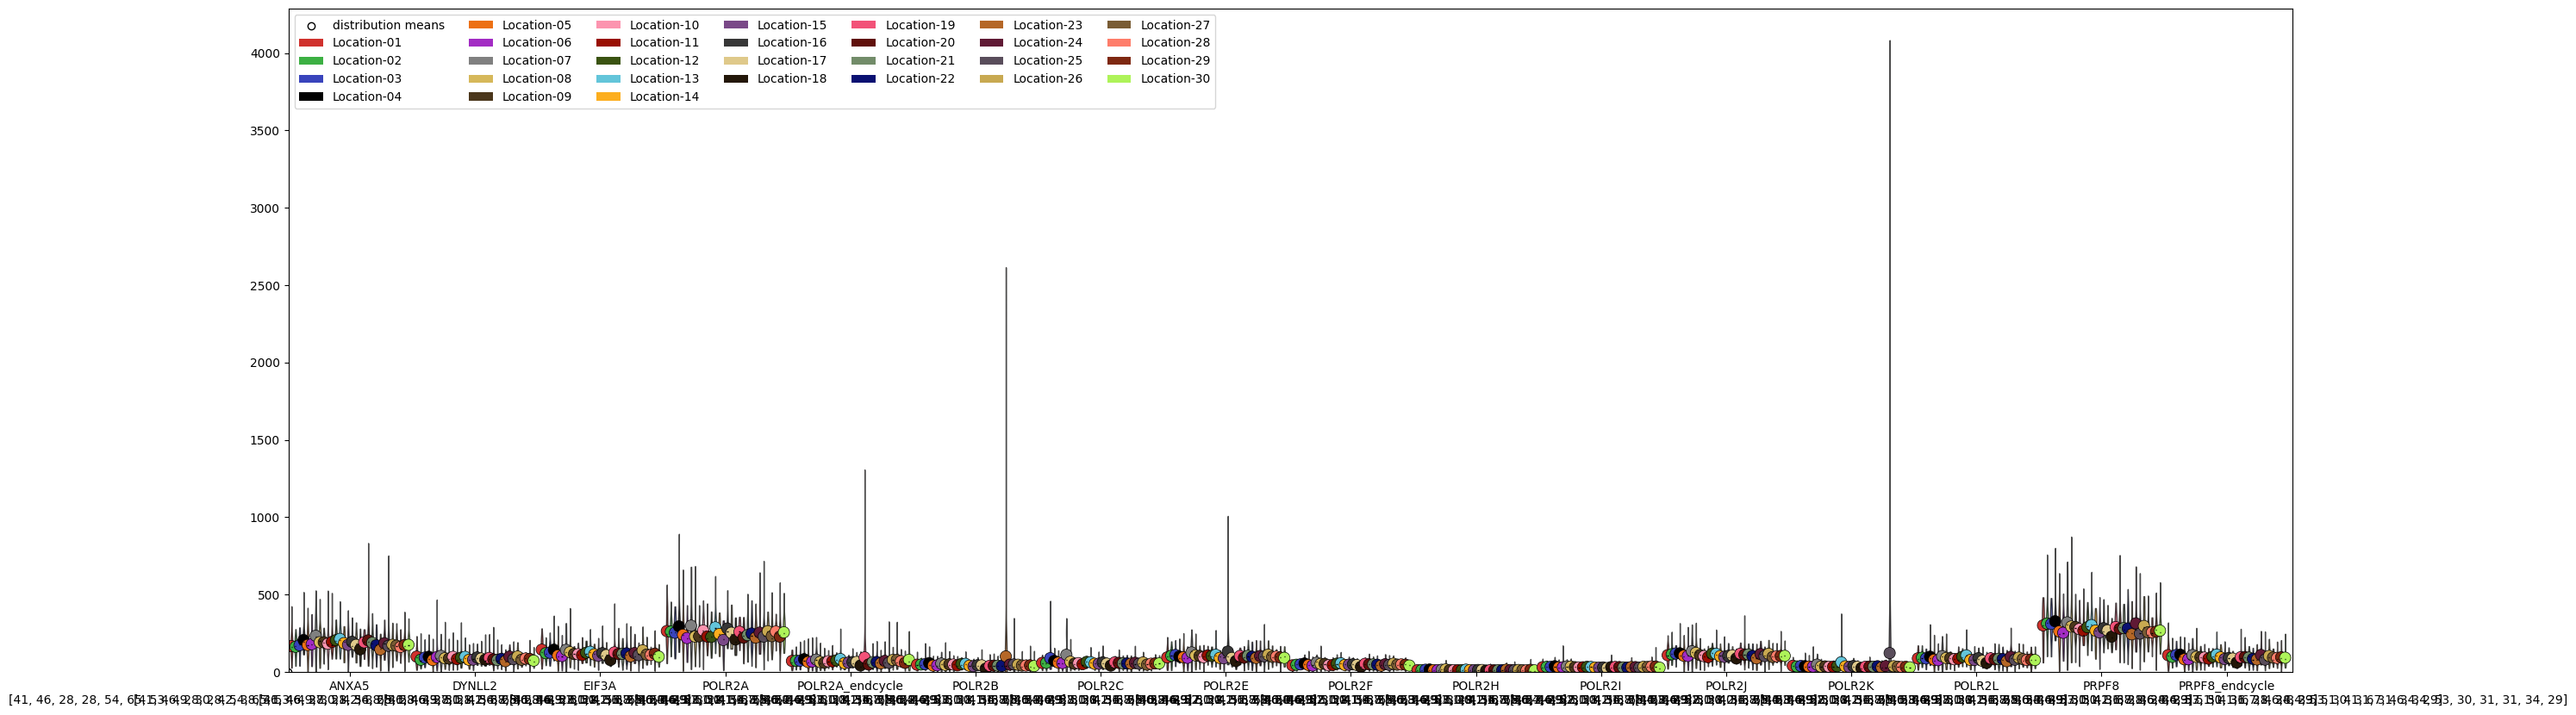

In [8]:
fig = plt.figure(figsize=(30,10))
ax = fig.gca()
ax = distribution_super_plot(
    data= data,
    ax=ax
)

# Check individual cell

In [9]:
LOCATION = "Location-01"
CELL_ID = 12

In [10]:
cell_view = Cell.loc[(Cell["location"] == LOCATION) & (Cell["label"] == CELL_ID)]
cell_view = safe_merge_no_duplicates(
    cell_view,
    Detection,
    keys=["target"],
    on="detection_id"
)
cell_view.loc[:,["location","detection_id","target","label"]].sort_values("detection_id")

,location,detection_id,target,label
0,Location-01,1,POLR2A,12
1,Location-01,2,Washout_1_0,12
2,Location-01,3,PRPF8,12
3,Location-01,4,Washout_3_0,12
4,Location-01,5,POLR2B,12
5,Location-01,6,Washout_5_0,12
6,Location-01,7,POLR2C,12
7,Location-01,8,Washout_7_0,12
8,Location-01,9,POLR2E,12
9,Location-01,10,Washout_9_0,12


In [11]:
Spots.loc[(Spots["location"] == LOCATION) & (Spots["cell_label"] == CELL_ID),["spot_id",'location','cell_label','coordinates',"detection_id","target"]].value_counts(subset=["location","cell_label","target"])

location     cell_label  target         
Location-01  12.0        PRPF8              443
                         POLR2A             391
                         ANXA5              232
                         EIF3A              211
                         DYNLL2             197
                         POLR2J             165
                         POLR2E             163
                         PRPF8_endcycle     125
                         POLR2L             123
                         POLR2A_endcycle    111
                         POLR2C             110
                         POLR2B              65
                         POLR2F              63
                         POLR2K              59
                         POLR2I              37
                         POLR2H              22
Name: count, dtype: int64

In [12]:
Spots_after_filter = pd.merge(
    Spots,
    Cell,
    how='outer',
    left_on=["location","detection_id","cell_label"],
    right_on=["location","detection_id",'label'],
    indicator=True
)
Spots_after_filter.loc[(Spots_after_filter["location"] == LOCATION)&(Spots_after_filter["cell_label"] == CELL_ID)].loc[:,["coordinates","intensity"]]

,coordinates,intensity
3733,"[10, 722, 701]",8420.0
3734,"[10, 756, 696]",8344.0
3735,"[13, 644, 661]",7602.0
3736,"[14, 685, 700]",8070.0
3737,"[15, 695, 727]",9026.0
...,...,...
68183,"[54, 908, 625]",7187.0
68184,"[54, 908, 626]",6230.0
68185,"[55, 908, 624]",5536.0
68186,"[55, 703, 722]",5432.0


In [13]:
Spots["population"].unique()

array(['free', 'clustered'], dtype=object)

# Duplicate spots to analyse foci and free populations

In [14]:
FOCI_RNAS = ["POLR2A","PRPF8"]

In [15]:
duplicate_spots_foci = Spots.loc[(Spots["target"].isin(FOCI_RNAS)) & (Spots["population"] == "clustered")]
duplicate_spots_foci["target"] = duplicate_spots_foci["target"].str.cat(['_clustered']*len(duplicate_spots_foci))

duplicate_spots_free = Spots.loc[(Spots["target"].isin(FOCI_RNAS)) & (Spots["population"] == "free")]
duplicate_spots_free["target"] = duplicate_spots_free["target"].str.cat(['_free']*len(duplicate_spots_free))
new_Spots = pd.concat([
    Spots,
    duplicate_spots_foci,
    duplicate_spots_free,
],axis=0)

/tmp/ipykernel_85126/3931015914.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplicate_spots_foci["target"] = duplicate_spots_foci["target"].str.cat(['_clustered']*len(duplicate_spots_foci))
/tmp/ipykernel_85126/3931015914.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplicate_spots_free["target"] = duplicate_spots_free["target"].str.cat(['_free']*len(duplicate_spots_free))


In [28]:
cluster_view = new_Spots.loc[new_Spots["target"] == "POLR2A_clustered"]
cluster_view.loc[:,["coordinates"]] = cluster_view["coordinates"].apply(tuple)
cluster_view.groupby(["location","cluster_id"]).agg({
    "coordinates" : [
        "count",
        lambda x : len(pd.unique(x)),
        pd.unique
    ]
})

coordinates             \
                             count <lambda_0>   
location    cluster_id                          
Location-01 0.0                  7          5   
            1.0                  7          5   
            2.0                  5          5   
            3.0                 13          7   
            4.0                  7          6   
...                            ...        ...   
Location-30 69.0                10          9   
            70.0                 5          4   
            71.0                 5          5   
            72.0                 6          5   
            73.0                 9          6   

                                                                           
                                                                   unique  
location    cluster_id                                                     
Location-01 0.0         [(5, 1306, 985), (5, 1307, 984), (5, 1307, 986...  
            1.0         [(9, 992, 425), (10, 993, 426), (10, 991, 424)...  
            2.0         [(10, 1339, 1045), (12, 1337, 1044), (12, 1339...  
            3.0         [(15, 1672, 482), (14, 1672, 481), (14, 1673, ...  
            4.0         [(23, 1197, 194), (22, 1197, 193), (24, 1198, ...  
...                                                                   ...  
Location-30 69.0        [(45, 724, 1009), (45, 724, 1008), (45, 725, 1...  
            70.0        [(44, 1208, 230), (44, 1209, 230), (43, 1210, ...  
            71.0        [(45, 1442, 1886), (44, 1443, 1886), (45, 1441...  
            72.0        [(45, 498, 1158), (47, 498, 1158), (45, 497, 1...  
            73.0        [(49, 1252, 1280), (49, 1251, 1280), (48, 1251...  

[3306 rows x 3 columns]

In [25]:
cluster_view[cluster_view["cluster_id"] == 0]

,spot_id,cluster_id,drifted_z,drifted_y,drifted_x,intensity,population,detection_id,acquisition_id,drift_z,...,cycle,color_id,is_washout,coordinates,in_nucleus,cell_label,location,target,voxel_size,fish_reodered_shape
4418,4418,0.0,5.0,1306.0,985.0,35748.0,clustered,1,0,0,...,0,0,False,"(5, 1306, 985)",True,39.0,Location-01,POLR2A_clustered,"[200, 97, 97]","[61, 1981, 2004, 3]"
4419,4419,0.0,5.0,1306.0,985.0,35748.0,clustered,1,0,0,...,0,0,False,"(5, 1306, 985)",True,39.0,Location-01,POLR2A_clustered,"[200, 97, 97]","[61, 1981, 2004, 3]"
4420,4420,0.0,5.0,1306.0,985.0,35748.0,clustered,1,0,0,...,0,0,False,"(5, 1306, 985)",True,39.0,Location-01,POLR2A_clustered,"[200, 97, 97]","[61, 1981, 2004, 3]"
4421,4421,0.0,5.0,1307.0,984.0,30237.0,clustered,1,0,0,...,0,0,False,"(5, 1307, 984)",True,39.0,Location-01,POLR2A_clustered,"[200, 97, 97]","[61, 1981, 2004, 3]"
4422,4422,0.0,5.0,1307.0,986.0,29819.0,clustered,1,0,0,...,0,0,False,"(5, 1307, 986)",True,39.0,Location-01,POLR2A_clustered,"[200, 97, 97]","[61, 1981, 2004, 3]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982431,1983437,0.0,15.0,332.0,191.0,18835.0,clustered,929,29,0,...,0,0,False,"(15, 332, 191)",True,28.0,Location-30,POLR2A_clustered,"[200, 97, 97]","[61, 1981, 2004, 3]"
1982432,1983438,0.0,16.0,331.0,189.0,17632.0,clustered,929,29,0,...,0,0,False,"(16, 331, 189)",True,28.0,Location-30,POLR2A_clustered,"[200, 97, 97]","[61, 1981, 2004, 3]"
1982434,1983440,0.0,15.0,332.0,192.0,17768.0,clustered,929,29,0,...,0,0,False,"(15, 332, 192)",True,28.0,Location-30,POLR2A_clustered,"[200, 97, 97]","[61, 1981, 2004, 3]"
1982435,1983441,0.0,17.0,333.0,189.0,14486.0,clustered,929,29,0,...,0,0,False,"(17, 333, 189)",True,28.0,Location-30,POLR2A_clustered,"[200, 97, 97]","[61, 1981, 2004, 3]"
